# Shared utilities / configuration

This notebook uses two uncertainty conventions.

Descriptive plots summarize independent model seeds as the mean across seeds with a 95% Student-t confidence interval. If only one seed is available, the CI is undefined and is shown as missing rather than as a zero-width interval.

Formal paired test-set contrasts use a paired patient-level bootstrap CI. Those intervals answer a different question from the model-seed CI and should not be interpreted as run-to-run variability across trained models.

In [1]:
# Keep exploratory cells permissive by default; final reported analyses should require complete seed sets.
EXP2A_ONLY_COMPLETE_RUNS = True

# Missing test predictions are always generated automatically.
# Set this to True only when intentionally regenerating ALL test predictions.
RERUN_ALL_TEST_INFERENCE = False

In [2]:
from pathlib import Path
import os
import re
import shlex
import subprocess

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from visualize_utils import (
    compute_prediction_metrics,
    compute_seed_paired_drop,
    expected_prediction_for_checkpoint,
    find_selected_checkpoint,
    float_token_pattern,
    plot_mean_ci_curve,
    read_validation_log,
    show_table,
    summarize_with_t_ci,
    warn_incomplete_seed_sets,
)

PROJECT_DATA_ROOT = Path(
    "/heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/"
    "physionet.org/files/mimiciv/1.0/russo"
)

EXP2A_REPO_DIR = Path.cwd().parent if Path.cwd().name == "visualizers" else Path.cwd()
EXP2A_PYTHON = os.environ.get("EXP2A_PYTHON", "python")
NETWORK = "mimic4models/keras_models/lstm.py"
EXPECTED_MODEL_SEEDS = {0, 1, 2, 3, 4}
EXPECTED_EPOCHS = 100

from visualize_utils import (
    load_prediction_csv as _load_prediction_frame,
    paired_patient_bootstrap as _paired_patient_bootstrap,
)

EXP2A_DATA_DIR = PROJECT_DATA_ROOT / "data/length-of-stay"
EXP2A_NORMALIZER_DIR = PROJECT_DATA_ROOT / "normalizers"
EXP2A_RESULTS_DIR = PROJECT_DATA_ROOT / "results/fixed_horizon_icu_exit"
EXP2A_OUTPUT_DIR = EXP2A_RESULTS_DIR / "plots"
EXP2A_HORIZONS = [12, 24, 48, 96, 168]
EXP2A_TIMESTEPS = [1, 2, 4, 8, 12, 16, 24]


EXP2A_EXPECTED_CONFIG = {
    "dim": 16,
    "depth": 2,
    "dropout": 0.3,
    "rec_dropout": 0.0,
    "batch_norm": False,
    "batch_size": 8,
    "optimizer": "adam",
    "lr": 0.001,
    "beta_1": 0.9,
    "l1": 0.0,
    "l2": 0.0,
    "target_repl_coef": 0.0,
    "imputation": "previous",
    "prefix": "",
}

EXP2A_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Missing test predictions: AUTO-RUN")
print("Rerun all existing test predictions:", RERUN_ALL_TEST_INFERENCE)
if RERUN_ALL_TEST_INFERENCE:
    print("WARNING: ALL eligible test predictions will be regenerated.")


def load_prediction_frame(path):
    return _load_prediction_frame(path)


def paired_patient_bootstrap(reference_df, comparison_df, metric, n_boot=2000, random_state=12345):
    result = _paired_patient_bootstrap(reference_df, comparison_df, metric, n_boot=n_boot, random_state=random_state)
    return {
        "reference_1h": result["left_metric"],
        "comparison": result["right_metric"],
        "difference": result["difference"],
        "ci_low": result["ci_low"],
        "ci_high": result["ci_high"],
        "n_patients": result["n_patients"],
        "n_stays": result["n_stays"],
        "n_boot_valid": result["n_boot_valid"],
    }

def plot_exp2a_panel(ax, summary, x_col, ylabel, x_order, series_col=None, series_order=None,
                     xlabel="", zero_line=False, raw_df=None, raw_metric=None):
    if summary is None or len(summary) == 0:
        ax.text(0.5, 0.5, "NOT AVAILABLE", transform=ax.transAxes, ha="center", va="center")
        ax.set_axis_off()
        return
    if series_col is None:
        sub = summary.sort_values(x_col)
        ax.errorbar(sub[x_col].values, sub["mean"].values, yerr=sub["ci95"].values,
                    marker="o", capsize=4, linewidth=2, markersize=6)
        if raw_df is not None and raw_metric is not None and len(raw_df):
            ax.scatter(raw_df[x_col].values, raw_df[raw_metric].values, alpha=0.25, s=18)
    else:
        for value in series_order:
            sub = summary[summary[series_col] == value].sort_values(x_col)
            if len(sub) == 0:
                continue
            ax.errorbar(sub[x_col].values, sub["mean"].values, yerr=sub["ci95"].values,
                        marker="o", capsize=4, linewidth=2, label="{}".format(value))
            if raw_df is not None and raw_metric is not None and len(raw_df):
                raw = raw_df[raw_df[series_col] == value]
                ax.scatter(raw[x_col].values, raw[raw_metric].values, alpha=0.20, s=16)
        ax.legend(title=series_col.replace("_", " "))
    if zero_line:
        ax.axhline(0, linestyle="--", linewidth=1, color="gray")
    ax.set_xticks(x_order)
    ax.set_xticklabels(["{}h".format(x) for x in x_order])
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(axis="y", alpha=0.25)


def plot_exp2a_two_panel(left_spec, right_spec, title, output_name):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5.2), sharex=False)
    for ax, spec in zip(axes, [left_spec.copy(), right_spec.copy()]):
        panel_title = spec.pop("panel_title")
        plot_exp2a_panel(ax, **spec)
        ax.set_title(panel_title)
    fig.suptitle(title, y=1.03)
    fig.tight_layout()
    output_path = EXP2A_OUTPUT_DIR / output_name
    fig.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", output_path)
    print("Error bars = 95% Student-t CI across model seeds; n=1 groups have undefined CI.")


Missing test predictions: AUTO-RUN
Rerun all existing test predictions: False


# Experiment 2A - Does frequency matter more for short horizons?

## Experiment question and expected evidence

Question: At a fixed prediction time of 24h after ICU admission, is the cost of coarser measurement frequency larger for short prediction horizons than for long prediction horizons?

Quantity: Performance-vs-resolution plots show AUPRC/AUROC by temporal resolution, with one curve per prediction horizon. Degradation plots compute Delta(h, r, s) = M(h, 1h, s) - M(h, r, s) within each seed, then summarize the paired drops across seeds with 95% Student-t CIs.

Evidence we are looking for: H2 is supported by larger positive degradation at short horizons, especially 12h, with smaller degradation at longer horizons. The longer horizons may form a plateau; perfect monotonic decline from 12h to 168h is not required.

Caveat: Raw AUPRC should not be compared directly across horizons because outcome prevalence differs by horizon. Delta relative to 1h and AUROC degradation are safer for cross-horizon sensitivity comparisons.

In [3]:
def _search(pattern, text, cast=None, default=None):
    m = re.search(pattern, text)
    if m is None:
        return default
    value = m.group(1)
    return cast(value) if cast is not None else value


def parse_exp2a_run(path):
    name = path.name
    m = re.search(
        r"\.h(?P<horizon>\d+)"
        r".*\.ts(?P<timestep>[0-9]+(?:\.[0-9]+)?)(?=\.|$)"
        r".*\.seed(?P<seed>\d+)(?:\.|$)",
        name,
    )
    if m is None:
        return None
    return {
        "horizon": int(m.group("horizon")),
        "timestep": float(m.group("timestep")),
        "seed": int(m.group("seed")),
        "dim": _search(r"\.n(\d+)", name, int, EXP2A_EXPECTED_CONFIG["dim"]),
        "depth": _search(r"\.dep(\d+)", name, int, EXP2A_EXPECTED_CONFIG["depth"]),
        "dropout": _search(r"\.d([0-9]+(?:\.[0-9]+)?)(?=\.dep|\.|$)", name, float, EXP2A_EXPECTED_CONFIG["dropout"]),
        "rec_dropout": _search(r"\.rd([0-9]+(?:\.[0-9]+)?)(?=\.|$)", name, float, EXP2A_EXPECTED_CONFIG["rec_dropout"]),
        "batch_norm": re.search(r"\.bn(?=\.|$)", name) is not None,
        "batch_size": _search(r"\.bs(\d+)", name, int, EXP2A_EXPECTED_CONFIG["batch_size"]),
        "l1": _search(r"\.L1([0-9.eE+-]+)(?=\.|$)", name, float, EXP2A_EXPECTED_CONFIG["l1"]),
        "l2": _search(r"\.L2([0-9.eE+-]+)(?=\.|$)", name, float, EXP2A_EXPECTED_CONFIG["l2"]),
        "target_repl_coef": _search(r"\.trc([0-9]+(?:\.[0-9]+)?)(?=\.|$)", name, float, EXP2A_EXPECTED_CONFIG["target_repl_coef"]),
    }


exp2a_val_rows = []
for horizon in EXP2A_HORIZONS:
    log_dir = EXP2A_RESULTS_DIR / "{}h".format(horizon) / "keras_logs"
    if not log_dir.exists():
        print("Missing log directory:", log_dir)
        continue
    for log_path in sorted(log_dir.glob("*.csv")):
        run = parse_exp2a_run(log_path)
        if run is None:
            print("Skipping unrecognized filename:", log_path.name)
            continue
        if run["horizon"] != horizon or run["timestep"] not in EXP2A_TIMESTEPS or run["seed"] not in EXPECTED_MODEL_SEEDS:
            continue
        best = read_validation_log(log_path, only_complete=EXP2A_ONLY_COMPLETE_RUNS)
        if best is None:
            print("Skipping empty/incomplete run:", log_path.name)
            continue
        checkpoint = find_selected_checkpoint(log_path, best["best_csv_epoch"])
        exp2a_val_rows.append({
            **run,
            **best,
            "log_path": str(log_path),
            "checkpoint": None if checkpoint is None else str(checkpoint),
        })

exp2a_val_runs = pd.DataFrame(exp2a_val_rows).sort_values(["horizon", "timestep", "seed"]).reset_index(drop=True)
show_table("Experiment 2A validation-selected checkpoints", exp2a_val_runs, max_rows=300)
warn_incomplete_seed_sets(exp2a_val_runs, ["horizon", "timestep"])


Experiment 2A validation-selected checkpoints


,batch_norm,batch_size,best_csv_epoch,best_val_auprc,best_val_epoch,checkpoint,checkpoint_epoch,complete,depth,dim,...,rec_dropout,seed,selected_validation_epoch,target_repl_coef,timestep,val_auprc,val_auroc,val_auroc_at_best_auprc,validation_auprc,validation_auroc
0,False,8,76,0.427847,76,/heinz-georgenas/users/mingzhul/Simultaneous-E...,77,True,1,16,...,0.0,0,76,0.0,1.0,0.427847,0.700517,0.700517,0.427847,0.700517
1,False,8,93,0.469834,93,/heinz-georgenas/users/mingzhul/Simultaneous-E...,94,True,2,16,...,0.0,0,93,0.0,1.0,0.469834,0.730083,0.730083,0.469834,0.730083
2,False,8,91,0.422889,91,/heinz-georgenas/users/mingzhul/Simultaneous-E...,92,True,1,16,...,0.0,1,91,0.0,1.0,0.422889,0.691622,0.691622,0.422889,0.691622
3,False,8,44,0.476230,44,/heinz-georgenas/users/mingzhul/Simultaneous-E...,45,True,2,16,...,0.0,1,44,0.0,1.0,0.476230,0.731720,0.731720,0.476230,0.731720
4,False,8,76,0.410104,76,/heinz-georgenas/users/mingzhul/Simultaneous-E...,77,True,1,16,...,0.0,2,76,0.0,1.0,0.410104,0.680926,0.680926,0.410104,0.680926
5,False,8,91,0.471504,91,/heinz-georgenas/users/mingzhul/Simultaneous-E...,92,True,2,16,...,0.0,2,91,0.0,1.0,0.471504,0.736019,0.736019,0.471504,0.736019
6,False,8,90,0.428522,90,/heinz-georgenas/users/mingzhul/Simultaneous-E...,91,True,1,16,...,0.0,3,90,0.0,1.0,0.428522,0.697431,0.697431,0.428522,0.697431
7,False,8,92,0.471724,92,/heinz-georgenas/users/mingzhul/Simultaneous-E...,93,True,2,16,...,0.0,3,92,0.0,1.0,0.471724,0.732311,0.732311,0.471724,0.732311
8,False,8,95,0.419127,95,/heinz-georgenas/users/mingzhul/Simultaneous-E...,96,True,1,16,...,0.0,4,95,0.0,1.0,0.419127,0.696639,0.696639,0.419127,0.696639
9,False,8,86,0.479264,86,/heinz-georgenas/users/mingzhul/Simultaneous-E...,87,True,2,16,...,0.0,4,86,0.0,1.0,0.479264,0.734050,0.734050,0.479264,0.734050


## Validation performance vs temporal resolution

Question: Within each prediction horizon, how does validation performance change as temporal resolution becomes coarser?

Quantity: X-axis is temporal resolution; y-axis is validation AUPRC or AUROC at the validation-AUPRC-selected epoch; curves are prediction horizons; error bars are mean across model seeds +/- 95% Student-t CI.

Evidence we are looking for: Similar fine-resolution performance with degradation at coarse resolutions suggests frequency sensitivity.

Caveat: Do not interpret raw AUPRC levels across horizons as directly comparable baselines because prevalence differs across horizons.


Experiment 2A validation AUPRC summary


,ci95,ci95_high,ci95_low,horizon,mean,n,sd,sem,timestep
0,0.020023,0.467728,0.427681,12,0.447704,10,0.027991,0.008851,1.0
1,0.002744,0.474141,0.468653,12,0.471397,5,0.002210,0.000988,2.0
2,0.001566,0.446294,0.443162,12,0.444728,5,0.001261,0.000564,4.0
3,0.003737,0.424239,0.416765,12,0.420502,5,0.003010,0.001346,8.0
4,0.003262,0.419302,0.412777,12,0.416039,5,0.002628,0.001175,12.0
5,0.001571,0.353816,0.350673,12,0.352244,5,0.001266,0.000566,24.0
6,0.004202,0.602648,0.594244,24,0.598446,5,0.003384,0.001513,1.0
7,0.003026,0.598713,0.592662,24,0.595687,5,0.002437,0.001090,2.0
8,0.003451,0.584589,0.577687,24,0.581138,5,0.002779,0.001243,4.0
9,0.001764,0.580559,0.577031,24,0.578795,5,0.001421,0.000635,8.0



Experiment 2A validation AUROC summary


,ci95,ci95_high,ci95_low,horizon,mean,n,sd,sem,timestep
0,0.015342,0.728474,0.697790,12,0.713132,10,0.021447,0.006782,1.0
1,0.001597,0.730748,0.727554,12,0.729151,5,0.001286,0.000575,2.0
2,0.002777,0.716739,0.711185,12,0.713962,5,0.002237,0.001000,4.0
3,0.001660,0.689128,0.685808,12,0.687468,5,0.001337,0.000598,8.0
4,0.002733,0.675831,0.670366,12,0.673099,5,0.002201,0.000984,12.0
5,0.002373,0.627947,0.623200,12,0.625574,5,0.001911,0.000855,24.0
6,0.002634,0.699519,0.694250,24,0.696884,5,0.002122,0.000949,1.0
7,0.002497,0.699236,0.694242,24,0.696739,5,0.002011,0.000899,2.0
8,0.001840,0.690314,0.686635,24,0.688475,5,0.001482,0.000663,4.0
9,0.001653,0.682442,0.679136,24,0.680789,5,0.001331,0.000595,8.0


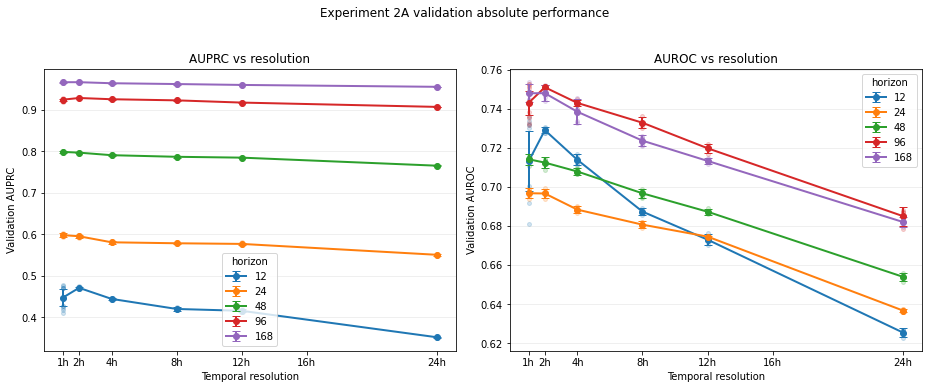

Saved: /heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/physionet.org/files/mimiciv/1.0/russo/results/fixed_horizon_icu_exit/plots/experiment2a_validation_absolute_performance_ci95.png
Error bars = 95% Student-t CI across model seeds; n=1 groups have undefined CI.


In [4]:
exp2a_val_auprc_summary = summarize_with_t_ci(exp2a_val_runs, ["horizon", "timestep"], "val_auprc")
exp2a_val_auroc_summary = summarize_with_t_ci(exp2a_val_runs, ["horizon", "timestep"], "val_auroc")
show_table("Experiment 2A validation AUPRC summary", exp2a_val_auprc_summary, max_rows=200)
show_table("Experiment 2A validation AUROC summary", exp2a_val_auroc_summary, max_rows=200)

plot_exp2a_two_panel(
    {
        "summary": exp2a_val_auprc_summary,
        "x_col": "timestep",
        "ylabel": "Validation AUPRC",
        "x_order": EXP2A_TIMESTEPS,
        "series_col": "horizon",
        "series_order": EXP2A_HORIZONS,
        "xlabel": "Temporal resolution",
        "raw_df": exp2a_val_runs,
        "raw_metric": "val_auprc",
        "panel_title": "AUPRC vs resolution",
    },
    {
        "summary": exp2a_val_auroc_summary,
        "x_col": "timestep",
        "ylabel": "Validation AUROC",
        "x_order": EXP2A_TIMESTEPS,
        "series_col": "horizon",
        "series_order": EXP2A_HORIZONS,
        "xlabel": "Temporal resolution",
        "raw_df": exp2a_val_runs,
        "raw_metric": "val_auroc",
        "panel_title": "AUROC vs resolution",
    },
    "Experiment 2A validation absolute performance",
    "experiment2a_validation_absolute_performance_ci95.png",
)


## Validation degradation relative to 1h

Question: Is the validation-performance cost of coarsening larger for near-term prediction?

Quantity: Delta(h, r, s) = M(h, 1h, s) - M(h, r, s), computed within seed before summarizing. X-axis is prediction horizon; one curve is shown for each temporal resolution; error bars are 95% Student-t CIs across paired seed-level drops.

Evidence we are looking for: Larger positive Delta at the 12h horizon than at longer horizons supports H2.

Caveat: Delta does not need to decrease perfectly monotonically across horizons. For AUPRC, compare degradation rather than raw cross-horizon levels.


Experiment 2A validation AUPRC drop from 1h


,ci95,ci95_high,ci95_low,horizon,mean,n,sd,sem,timestep
0,0.020044,-0.003649,-0.043737,12,-0.023693,10,0.028019,0.008861,2.0
1,0.019972,0.022949,-0.016995,12,0.002977,10,0.027919,0.008829,4.0
2,0.020365,0.047568,0.006837,12,0.027202,10,0.028469,0.009003,8.0
3,0.020115,0.051780,0.011550,12,0.031665,10,0.028119,0.008892,12.0
4,0.019960,0.115420,0.075500,12,0.095460,10,0.027902,0.008823,24.0
5,0.002223,0.004982,0.000536,24,0.002759,5,0.001790,0.000801,2.0
6,0.004176,0.021485,0.013132,24,0.017308,5,0.003364,0.001504,4.0
7,0.003500,0.023151,0.016151,24,0.019651,5,0.002819,0.001261,8.0
8,0.007007,0.028210,0.014197,24,0.021203,5,0.005643,0.002524,12.0
9,0.004565,0.052008,0.042879,24,0.047444,5,0.003676,0.001644,24.0



Experiment 2A validation AUROC drop from 1h


,ci95,ci95_high,ci95_low,horizon,mean,n,sd,sem,timestep
0,0.015334,-0.000685,-0.031352,12,-0.016019,10,0.021435,0.006778,2.0
1,0.015299,0.014469,-0.016129,12,-0.000830,10,0.021387,0.006763,4.0
2,0.015386,0.041050,0.010278,12,0.025664,10,0.021509,0.006802,8.0
3,0.015411,0.055444,0.024623,12,0.040033,10,0.021543,0.006812,12.0
4,0.015283,0.102842,0.072275,12,0.087558,10,0.021365,0.006756,24.0
5,0.003783,0.003928,-0.003637,24,0.000145,5,0.003047,0.001362,2.0
6,0.001649,0.010059,0.006761,24,0.008410,5,0.001328,0.000594,4.0
7,0.002926,0.019021,0.013169,24,0.016095,5,0.002356,0.001054,8.0
8,0.002810,0.025028,0.019408,24,0.022218,5,0.002263,0.001012,12.0
9,0.002775,0.062825,0.057274,24,0.060049,5,0.002235,0.001000,24.0


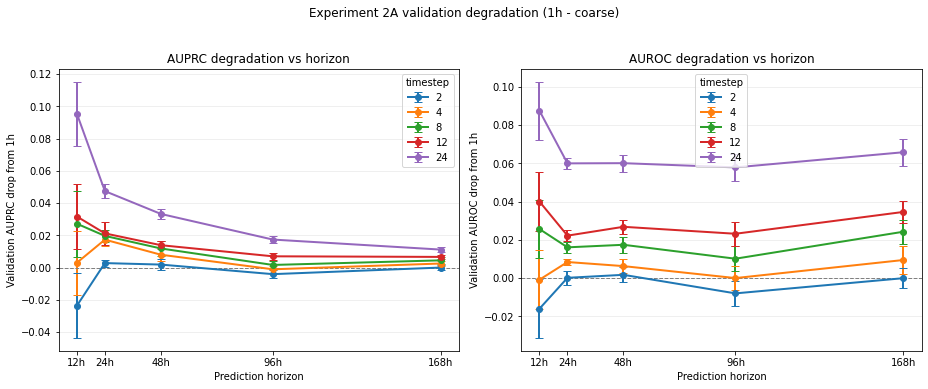

Saved: /heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/physionet.org/files/mimiciv/1.0/russo/results/fixed_horizon_icu_exit/plots/experiment2a_validation_degradation_ci95.png
Error bars = 95% Student-t CI across model seeds; n=1 groups have undefined CI.


In [5]:
exp2a_val_auprc_drops = compute_seed_paired_drop(exp2a_val_runs, ["horizon"], "timestep", 1.0, "val_auprc", drop_col="drop")
exp2a_val_auroc_drops = compute_seed_paired_drop(exp2a_val_runs, ["horizon"], "timestep", 1.0, "val_auroc", drop_col="drop")
exp2a_val_auprc_drops = exp2a_val_auprc_drops[exp2a_val_auprc_drops["timestep"] != 1.0].copy()
exp2a_val_auroc_drops = exp2a_val_auroc_drops[exp2a_val_auroc_drops["timestep"] != 1.0].copy()
exp2a_val_auprc_drop_summary = summarize_with_t_ci(exp2a_val_auprc_drops, ["horizon", "timestep"], "drop")
exp2a_val_auroc_drop_summary = summarize_with_t_ci(exp2a_val_auroc_drops, ["horizon", "timestep"], "drop")
show_table("Experiment 2A validation AUPRC drop from 1h", exp2a_val_auprc_drop_summary, max_rows=200)
show_table("Experiment 2A validation AUROC drop from 1h", exp2a_val_auroc_drop_summary, max_rows=200)

plot_exp2a_two_panel(
    {
        "summary": exp2a_val_auprc_drop_summary,
        "x_col": "horizon",
        "ylabel": "Validation AUPRC drop from 1h",
        "x_order": EXP2A_HORIZONS,
        "series_col": "timestep",
        "series_order": [x for x in EXP2A_TIMESTEPS if x != 1],
        "xlabel": "Prediction horizon",
        "zero_line": True,
        "panel_title": "AUPRC degradation vs horizon",
    },
    {
        "summary": exp2a_val_auroc_drop_summary,
        "x_col": "horizon",
        "ylabel": "Validation AUROC drop from 1h",
        "x_order": EXP2A_HORIZONS,
        "series_col": "timestep",
        "series_order": [x for x in EXP2A_TIMESTEPS if x != 1],
        "xlabel": "Prediction horizon",
        "zero_line": True,
        "panel_title": "AUROC degradation vs horizon",
    },
    "Experiment 2A validation degradation (1h - coarse)",
    "experiment2a_validation_degradation_ci95.png",
)


## Test performance vs temporal resolution

Question: Do the validation-selected checkpoints show the same frequency-sensitivity pattern on the held-out test set?

Quantity: Test AUPRC/AUROC are computed only from prediction files linked exactly to the validation-selected checkpoint filename. Error bars are mean across model seeds +/- 95% Student-t CI.

Evidence we are looking for: The same threshold-like or short-horizon-sensitive degradation pattern on test data strengthens the validation finding.

Caveat: Test data are not used for model selection. Missing exact prediction files are reported rather than replaced by loose `(horizon, timestep, seed)` or mtime-based matches.


Experiment 2A exact validation-selected test predictions


,batch_norm,batch_size,best_csv_epoch,best_val_auprc,best_val_epoch,checkpoint,checkpoint_epoch,complete,depth,dim,...,selected_validation_epoch,target_repl_coef,test_auprc,test_auroc,timestep,val_auprc,val_auroc,val_auroc_at_best_auprc,validation_auprc,validation_auroc
0,False,8,76,0.427847,76,/heinz-georgenas/users/mingzhul/Simultaneous-E...,77,True,1,16,...,76,0.0,0.442138,0.703870,1.0,0.427847,0.700517,0.700517,0.427847,0.700517
1,False,8,93,0.469834,93,/heinz-georgenas/users/mingzhul/Simultaneous-E...,94,True,2,16,...,93,0.0,0.491179,0.746718,1.0,0.469834,0.730083,0.730083,0.469834,0.730083
2,False,8,91,0.422889,91,/heinz-georgenas/users/mingzhul/Simultaneous-E...,92,True,1,16,...,91,0.0,0.434706,0.698212,1.0,0.422889,0.691622,0.691622,0.422889,0.691622
3,False,8,44,0.476230,44,/heinz-georgenas/users/mingzhul/Simultaneous-E...,45,True,2,16,...,44,0.0,0.490433,0.741809,1.0,0.476230,0.731720,0.731720,0.476230,0.731720
4,False,8,76,0.410104,76,/heinz-georgenas/users/mingzhul/Simultaneous-E...,77,True,1,16,...,76,0.0,0.413350,0.689697,1.0,0.410104,0.680926,0.680926,0.410104,0.680926
5,False,8,91,0.471504,91,/heinz-georgenas/users/mingzhul/Simultaneous-E...,92,True,2,16,...,91,0.0,0.489568,0.744989,1.0,0.471504,0.736019,0.736019,0.471504,0.736019
6,False,8,90,0.428522,90,/heinz-georgenas/users/mingzhul/Simultaneous-E...,91,True,1,16,...,90,0.0,0.440518,0.703327,1.0,0.428522,0.697431,0.697431,0.428522,0.697431
7,False,8,92,0.471724,92,/heinz-georgenas/users/mingzhul/Simultaneous-E...,93,True,2,16,...,92,0.0,0.488332,0.744828,1.0,0.471724,0.732311,0.732311,0.471724,0.732311
8,False,8,95,0.419127,95,/heinz-georgenas/users/mingzhul/Simultaneous-E...,96,True,1,16,...,95,0.0,0.438183,0.706684,1.0,0.419127,0.696639,0.696639,0.419127,0.696639
9,False,8,86,0.479264,86,/heinz-georgenas/users/mingzhul/Simultaneous-E...,87,True,2,16,...,86,0.0,0.489575,0.743362,1.0,0.479264,0.734050,0.734050,0.479264,0.734050



Experiment 2A missing exact test predictions
<none>

Experiment 2A test AUPRC summary


,ci95,ci95_high,ci95_low,horizon,mean,n,sd,sem,timestep
0,0.021865,0.483663,0.439933,12,0.461798,10,0.030565,0.009666,1.0
1,0.004573,0.488435,0.479290,12,0.483862,5,0.003683,0.001647,2.0
2,0.003701,0.470781,0.463378,12,0.467079,5,0.002981,0.001333,4.0
3,0.005576,0.417952,0.406800,12,0.412376,5,0.004491,0.002008,8.0
4,0.002329,0.418581,0.413923,12,0.416252,5,0.001875,0.000839,12.0
5,0.004451,0.343028,0.334126,12,0.338577,5,0.003585,0.001603,24.0
6,0.002951,0.611442,0.605541,24,0.608492,5,0.002376,0.001063,1.0
7,0.005113,0.605963,0.595736,24,0.600849,5,0.004118,0.001842,2.0
8,0.003723,0.602237,0.594792,24,0.598515,5,0.002998,0.001341,4.0
9,0.002902,0.581486,0.575683,24,0.578585,5,0.002337,0.001045,8.0



Experiment 2A test AUROC summary


,ci95,ci95_high,ci95_low,horizon,mean,n,sd,sem,timestep
0,0.016911,0.739260,0.705439,12,0.722350,10,0.023639,0.007475,1.0
1,0.002787,0.743236,0.737663,12,0.740450,5,0.002244,0.001004,2.0
2,0.002112,0.736210,0.731985,12,0.734098,5,0.001701,0.000761,4.0
3,0.003506,0.697109,0.690096,12,0.693602,5,0.002824,0.001263,8.0
4,0.002875,0.690560,0.684809,12,0.687685,5,0.002316,0.001036,12.0
5,0.004207,0.628873,0.620460,12,0.624666,5,0.003388,0.001515,24.0
6,0.003057,0.704947,0.698834,24,0.701891,5,0.002462,0.001101,1.0
7,0.002535,0.697954,0.692884,24,0.695419,5,0.002042,0.000913,2.0
8,0.002396,0.696502,0.691710,24,0.694106,5,0.001930,0.000863,4.0
9,0.001659,0.676680,0.673362,24,0.675021,5,0.001336,0.000598,8.0


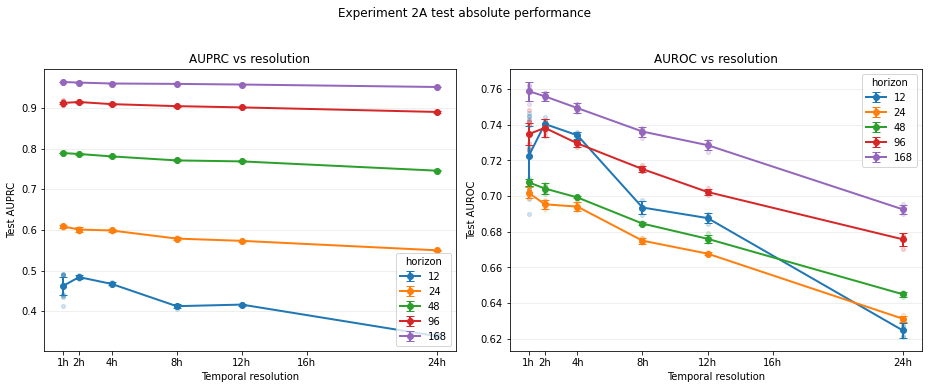

Saved: /heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/physionet.org/files/mimiciv/1.0/russo/results/fixed_horizon_icu_exit/plots/experiment2a_test_absolute_performance_ci95.png
Error bars = 95% Student-t CI across model seeds; n=1 groups have undefined CI.


In [6]:
def quote_command(cmd):
    return " ".join(shlex.quote(str(x)) for x in cmd)


def find_exp2a_normalizer(timestep):
    pattern = "fixed_horizon_icu_exit_ts:{:.2f}_impute:previous_start:zero_masks:True_n:*.normalizer".format(float(timestep))
    candidates = sorted(EXP2A_NORMALIZER_DIR.glob(pattern))
    if len(candidates) != 1:
        raise RuntimeError("Expected exactly one Experiment 2A normalizer for pattern {} but found {}:\n{}".format(
            pattern, len(candidates), candidates))
    return candidates[0]


def build_exp2a_test_inference_command(row, checkpoint):
    output_dir = EXP2A_RESULTS_DIR / "{}h".format(int(row["horizon"]))
    cmd = [
        EXP2A_PYTHON, "-m", "mimic4models.fixed_horizon_icu_exit.main",
        "--mode", "test",
        "--network", NETWORK,
        "--data", str(EXP2A_DATA_DIR),
        "--output_dir", str(output_dir),
        "--normalizer_dir", str(EXP2A_NORMALIZER_DIR),
        "--normalizer_state", str(find_exp2a_normalizer(row["timestep"])),
        "--load_state", str(checkpoint),
        "--horizon", str(int(row["horizon"])),
        "--timestep", str(float(row["timestep"])),
        "--seed", str(int(row["seed"])),
        "--dim", str(int(row["dim"])),
        "--depth", str(int(row["depth"])),
        "--dropout", str(row["dropout"]),
        "--rec_dropout", str(row["rec_dropout"]),
        "--batch_size", str(int(row["batch_size"])),
        "--optimizer", EXP2A_EXPECTED_CONFIG["optimizer"],
        "--lr", str(EXP2A_EXPECTED_CONFIG["lr"]),
        "--beta_1", str(EXP2A_EXPECTED_CONFIG["beta_1"]),
        "--l1", str(row["l1"]),
        "--l2", str(row["l2"]),
        "--target_repl_coef", str(row["target_repl_coef"]),
        "--imputation", EXP2A_EXPECTED_CONFIG["imputation"],
        "--prefix", EXP2A_EXPECTED_CONFIG["prefix"],
        "--sampling_strategy", "none",
    ]
    if bool(row.get("batch_norm")):
        cmd += ["--batch_norm", "True"]
    return cmd


def ensure_exp2a_prediction(row, checkpoint, prediction_path):
    cmd = build_exp2a_test_inference_command(row, checkpoint)
    if prediction_path.exists():
        if not RERUN_ALL_TEST_INFERENCE:
            return prediction_path
        print("RERUN_ALL_TEST_INFERENCE=True")
        print("Regenerating existing prediction:")
        print(prediction_path)
        print(quote_command(cmd))
    else:
        print("Missing test prediction; running inference:")
        print(prediction_path)
        print(quote_command(cmd))
    subprocess.check_call(cmd, cwd=str(EXP2A_REPO_DIR))
    if not prediction_path.exists():
        raise RuntimeError("Test inference completed but exact prediction file is missing: {}".format(prediction_path))
    return prediction_path


exp2a_test_rows = []
exp2a_missing_predictions = []

for _, row in exp2a_val_runs.iterrows():
    if not row.get("checkpoint"):
        exp2a_missing_predictions.append({**row.to_dict(), "reason": "missing selected checkpoint"})
        continue
    checkpoint = Path(row["checkpoint"])
    prediction_path = expected_prediction_for_checkpoint(EXP2A_RESULTS_DIR, "{}".format(int(row["horizon"])), checkpoint)
    ensure_exp2a_prediction(row, checkpoint, prediction_path)
    metrics = compute_prediction_metrics(prediction_path)
    exp2a_test_rows.append({**row.to_dict(), **metrics, "prediction_path": str(prediction_path)})

exp2a_test_runs = pd.DataFrame(exp2a_test_rows)
if len(exp2a_test_runs):
    exp2a_test_runs = exp2a_test_runs.sort_values(["horizon", "timestep", "seed"]).reset_index(drop=True)
exp2a_missing_predictions = pd.DataFrame(exp2a_missing_predictions)

show_table("Experiment 2A exact validation-selected test predictions", exp2a_test_runs, max_rows=300)
show_table("Experiment 2A missing exact test predictions", exp2a_missing_predictions, max_rows=300)
warn_incomplete_seed_sets(exp2a_test_runs, ["horizon", "timestep"])

if len(exp2a_test_runs):
    exp2a_test_auprc_summary = summarize_with_t_ci(exp2a_test_runs, ["horizon", "timestep"], "test_auprc")
    exp2a_test_auroc_summary = summarize_with_t_ci(exp2a_test_runs, ["horizon", "timestep"], "test_auroc")
    show_table("Experiment 2A test AUPRC summary", exp2a_test_auprc_summary, max_rows=200)
    show_table("Experiment 2A test AUROC summary", exp2a_test_auroc_summary, max_rows=200)
    plot_exp2a_two_panel(
        {
            "summary": exp2a_test_auprc_summary,
            "x_col": "timestep",
            "ylabel": "Test AUPRC",
            "x_order": EXP2A_TIMESTEPS,
            "series_col": "horizon",
            "series_order": EXP2A_HORIZONS,
            "xlabel": "Temporal resolution",
            "raw_df": exp2a_test_runs,
            "raw_metric": "test_auprc",
            "panel_title": "AUPRC vs resolution",
        },
        {
            "summary": exp2a_test_auroc_summary,
            "x_col": "timestep",
            "ylabel": "Test AUROC",
            "x_order": EXP2A_TIMESTEPS,
            "series_col": "horizon",
            "series_order": EXP2A_HORIZONS,
            "xlabel": "Temporal resolution",
            "raw_df": exp2a_test_runs,
            "raw_metric": "test_auroc",
            "panel_title": "AUROC vs resolution",
        },
        "Experiment 2A test absolute performance",
        "experiment2a_test_absolute_performance_ci95.png",
    )
else:
    print("No exact validation-selected Experiment 2A test predictions available.")


## Test degradation relative to 1h

Question: On the held-out test set, is the performance cost of coarsening larger for near-term prediction?

Quantity: Test Delta(h, r, s) is computed within each seed from exact validation-selected predictions, then summarized across seeds with 95% Student-t CIs.

Evidence we are looking for: Larger positive Delta at short horizons, especially 12h, supports H2.

Caveat: The model-seed CI describes variability across trained models. It is not the same uncertainty estimate as the paired patient bootstrap below.


Experiment 2A test AUPRC drop from 1h


,ci95,ci95_high,ci95_low,horizon,mean,n,sd,sem,timestep
0,0.022039,-0.000025,-0.044103,12,-0.022064,10,0.030808,0.009742,2.0
1,0.022261,0.016980,-0.027542,12,-0.005281,10,0.031119,0.009841,4.0
2,0.021667,0.071089,0.027755,12,0.049422,10,0.030288,0.009578,8.0
3,0.021920,0.067466,0.023626,12,0.045546,10,0.030643,0.009690,12.0
4,0.021826,0.145047,0.101395,12,0.123221,10,0.030511,0.009648,24.0
5,0.006932,0.014574,0.000710,24,0.007642,5,0.005583,0.002497,2.0
6,0.005255,0.015231,0.004722,24,0.009977,5,0.004232,0.001893,4.0
7,0.003062,0.032969,0.026845,24,0.029907,5,0.002466,0.001103,8.0
8,0.004339,0.039815,0.031137,24,0.035476,5,0.003495,0.001563,12.0
9,0.003022,0.061751,0.055708,24,0.058729,5,0.002433,0.001088,24.0



Experiment 2A test AUROC drop from 1h


,ci95,ci95_high,ci95_low,horizon,mean,n,sd,sem,timestep
0,0.016958,-0.001142,-0.035058,12,-0.018100,10,0.023706,0.007496,2.0
1,0.017062,0.005313,-0.028810,12,-0.011748,10,0.023850,0.007542,4.0
2,0.016848,0.045596,0.011899,12,0.028748,10,0.023553,0.007448,8.0
3,0.016960,0.051624,0.017705,12,0.034665,10,0.023708,0.007497,12.0
4,0.016984,0.114667,0.080700,12,0.097683,10,0.023741,0.007508,24.0
5,0.004226,0.010698,0.002245,24,0.006472,5,0.003404,0.001522,2.0
6,0.004447,0.012232,0.003338,24,0.007785,5,0.003582,0.001602,4.0
7,0.003099,0.029969,0.023770,24,0.026870,5,0.002496,0.001116,8.0
8,0.003430,0.037582,0.030722,24,0.034152,5,0.002762,0.001235,12.0
9,0.002497,0.073149,0.068155,24,0.070652,5,0.002011,0.000899,24.0


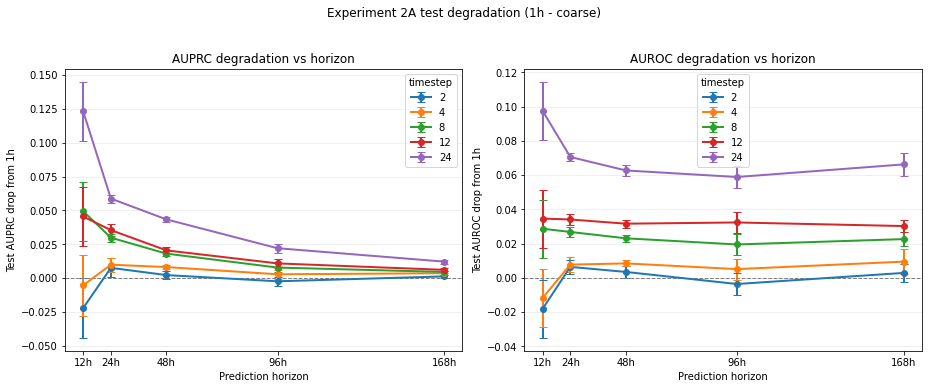

Saved: /heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/physionet.org/files/mimiciv/1.0/russo/results/fixed_horizon_icu_exit/plots/experiment2a_test_degradation_ci95.png
Error bars = 95% Student-t CI across model seeds; n=1 groups have undefined CI.


In [7]:
if len(exp2a_test_runs):
    exp2a_test_auprc_drops = compute_seed_paired_drop(exp2a_test_runs, ["horizon"], "timestep", 1.0, "test_auprc", drop_col="drop")
    exp2a_test_auroc_drops = compute_seed_paired_drop(exp2a_test_runs, ["horizon"], "timestep", 1.0, "test_auroc", drop_col="drop")
    exp2a_test_auprc_drops = exp2a_test_auprc_drops[exp2a_test_auprc_drops["timestep"] != 1.0].copy()
    exp2a_test_auroc_drops = exp2a_test_auroc_drops[exp2a_test_auroc_drops["timestep"] != 1.0].copy()
    exp2a_test_auprc_drop_summary = summarize_with_t_ci(exp2a_test_auprc_drops, ["horizon", "timestep"], "drop")
    exp2a_test_auroc_drop_summary = summarize_with_t_ci(exp2a_test_auroc_drops, ["horizon", "timestep"], "drop")
    show_table("Experiment 2A test AUPRC drop from 1h", exp2a_test_auprc_drop_summary, max_rows=200)
    show_table("Experiment 2A test AUROC drop from 1h", exp2a_test_auroc_drop_summary, max_rows=200)
    plot_exp2a_two_panel(
        {
            "summary": exp2a_test_auprc_drop_summary,
            "x_col": "horizon",
            "ylabel": "Test AUPRC drop from 1h",
            "x_order": EXP2A_HORIZONS,
            "series_col": "timestep",
            "series_order": [x for x in EXP2A_TIMESTEPS if x != 1],
            "xlabel": "Prediction horizon",
            "zero_line": True,
            "panel_title": "AUPRC degradation vs horizon",
        },
        {
            "summary": exp2a_test_auroc_drop_summary,
            "x_col": "horizon",
            "ylabel": "Test AUROC drop from 1h",
            "x_order": EXP2A_HORIZONS,
            "series_col": "timestep",
            "series_order": [x for x in EXP2A_TIMESTEPS if x != 1],
            "xlabel": "Prediction horizon",
            "zero_line": True,
            "panel_title": "AUROC degradation vs horizon",
        },
        "Experiment 2A test degradation (1h - coarse)",
        "experiment2a_test_degradation_ci95.png",
    )
else:
    print("No Experiment 2A exact test predictions available for degradation plots.")


## Paired patient bootstrap analysis

Question: Are the observed test-set differences between 1h and coarser resolutions stable to resampling the patient population?

Quantity: For AUROC, AUPRC, and Brier, predictions are paired on the same stays/patients and bootstrapped by patient. Positive differences mean the 1h/reference condition is better; for Brier this uses the reversed sign because lower Brier is better.

Evidence we are looking for: Positive paired differences whose 95% patient-bootstrap CI excludes zero indicate stable test-set degradation for that horizon/resolution/seed.

Caveat: This is a patient-population uncertainty estimate, not a model-seed CI and not a replacement for the descriptive across-seed plots above.

In [8]:
EXP2A_BOOT_METRICS = ["auroc", "auprc", "brier"]
EXP2A_N_BOOT = int(os.environ.get("EXP2A_N_BOOT", "2000"))
EXP2A_BOOTSTRAP_SEED = 12345
exp2a_prediction_frames = {}

if len(exp2a_test_runs):
    for _, row in exp2a_test_runs.iterrows():
        exp2a_prediction_frames[(row["horizon"], row["timestep"], row["seed"])] = load_prediction_frame(row["prediction_path"])

exp2a_bootstrap_rows = []
for horizon in EXP2A_HORIZONS:
    for seed in sorted(EXPECTED_MODEL_SEEDS):
        reference_key = (horizon, 1.0, seed)
        if reference_key not in exp2a_prediction_frames:
            continue
        reference_df = exp2a_prediction_frames[reference_key]
        for timestep in [x for x in EXP2A_TIMESTEPS if x != 1]:
            comparison_key = (horizon, float(timestep), seed)
            if comparison_key not in exp2a_prediction_frames:
                continue
            comparison_df = exp2a_prediction_frames[comparison_key]
            for metric in EXP2A_BOOT_METRICS:
                result = paired_patient_bootstrap(
                    reference_df,
                    comparison_df,
                    metric=metric,
                    n_boot=EXP2A_N_BOOT,
                    random_state=EXP2A_BOOTSTRAP_SEED + horizon * 100 + timestep * 10 + seed,
                )
                exp2a_bootstrap_rows.append({
                    "horizon": horizon,
                    "timestep": timestep,
                    "seed": seed,
                    "metric": metric,
                    **result,
                })

exp2a_bootstrap = pd.DataFrame(exp2a_bootstrap_rows)
if len(exp2a_bootstrap):
    exp2a_bootstrap = exp2a_bootstrap.sort_values(["metric", "horizon", "timestep", "seed"]).reset_index(drop=True)
show_table("Experiment 2A seed-level paired patient-bootstrap 95% CI", exp2a_bootstrap, max_rows=300)


Experiment 2A seed-level paired patient-bootstrap 95% CI


,ci_high,ci_low,comparison,difference,horizon,metric,n_boot_valid,n_patients,n_stays,reference_1h,seed,timestep
0,0.020561,-0.007108,0.484856,0.006322,12,auprc,2000,5643,6757,0.491179,0,2
1,0.020344,-0.002876,0.480740,0.009693,12,auprc,2000,5643,6757,0.490433,1,2
2,0.016110,-0.007186,0.484753,0.004814,12,auprc,2000,5643,6757,0.489568,2,2
3,0.020659,-0.003889,0.479901,0.008431,12,auprc,2000,5643,6757,0.488332,3,2
4,0.012013,-0.011073,0.489061,0.000515,12,auprc,2000,5643,6757,0.489575,4,2
5,0.042814,0.013041,0.463364,0.027815,12,auprc,2000,5643,6757,0.491179,0,4
6,0.039996,0.009152,0.465747,0.024686,12,auprc,2000,5643,6757,0.490433,1,4
7,0.032788,0.004492,0.471104,0.018464,12,auprc,2000,5643,6757,0.489568,2,4
8,0.037101,0.007787,0.466318,0.022014,12,auprc,2000,5643,6757,0.488332,3,4
9,0.036097,0.006353,0.468864,0.020712,12,auprc,2000,5643,6757,0.489575,4,4


... 75 more rows


In [9]:
# ============================================================
# Across-seed summary of paired patient-bootstrap contrasts
# ============================================================

from visualize_utils import across_seed_patient_bootstrap

exp2a_bootstrap_summary_rows = []

if len(exp2a_bootstrap):
    group_cols = ["horizon", "timestep", "metric"]

    for keys, group in exp2a_bootstrap.groupby(group_cols):
        horizon, timestep, metric = keys

        seeds = sorted(group["seed"].unique())
        diffs = group["difference"].values

        bootstrap_keys = [
            (
                seed,
                (horizon, 1.0, seed),
                (horizon, float(timestep), seed),
            )
            for seed in seeds
        ]

        boot = across_seed_patient_bootstrap(
            exp2a_prediction_frames,
            bootstrap_keys,
            metric=metric,
            n_boot=EXP2A_N_BOOT,
            random_state=(
                EXP2A_BOOTSTRAP_SEED
                + int(horizon) * 10000
                + int(timestep) * 100
                + EXP2A_BOOT_METRICS.index(metric)
            ),
        )

        exp2a_bootstrap_summary_rows.append({
            "horizon": horizon,
            "timestep": timestep,
            "metric": metric,

            # Mean absolute performance across model seeds
            "reference_1h_mean":
                float(np.mean(group["reference_1h"].values)),

            "comparison_mean":
                float(np.mean(group["comparison"].values)),

            # Mean 1h - coarse-resolution degradation
            "mean_difference":
                float(np.mean(diffs)),

            "sd_difference":
                float(np.std(diffs, ddof=1))
                if len(diffs) > 1 else np.nan,

            # Seed completeness
            "n_seeds":
                int(len(seeds)),

            "expected_seeds":
                len(EXPECTED_MODEL_SEEDS),

            "complete_seed_set":
                set(seeds) == set(EXPECTED_MODEL_SEEDS),

            # Across-seed paired patient-bootstrap CI
            "patient_bootstrap_ci_low":
                boot["patient_bootstrap_ci_low"],

            "patient_bootstrap_ci_high":
                boot["patient_bootstrap_ci_high"],
        })

        if set(seeds) != set(EXPECTED_MODEL_SEEDS):
            print(
                "PARTIAL SEED SET: h={} timestep={} metric={} "
                "observed={} missing={} extra={}".format(
                    horizon,
                    timestep,
                    metric,
                    sorted(seeds),
                    sorted(
                        set(EXPECTED_MODEL_SEEDS) - set(seeds)
                    ),
                    sorted(
                        set(seeds) - set(EXPECTED_MODEL_SEEDS)
                    ),
                )
            )

exp2a_bootstrap_summary = pd.DataFrame(
    exp2a_bootstrap_summary_rows
)

if len(exp2a_bootstrap_summary):
    exp2a_bootstrap_summary = (
        exp2a_bootstrap_summary
        .sort_values(
            ["metric", "horizon", "timestep"]
        )
        .reset_index(drop=True)
    )

show_table(
    "Experiment 2A across-seed paired-bootstrap summary",
    exp2a_bootstrap_summary,
    max_rows=300,
)


Experiment 2A across-seed paired-bootstrap summary


,comparison_mean,complete_seed_set,expected_seeds,horizon,mean_difference,metric,n_seeds,patient_bootstrap_ci_high,patient_bootstrap_ci_low,reference_1h_mean,sd_difference,timestep
0,0.483862,True,5,12,0.005955,auprc,5,0.014196,-0.002410,0.489817,0.003576,2
1,0.467079,True,5,12,0.022738,auprc,5,0.034793,0.010645,0.489817,0.003622,4
2,0.412376,True,5,12,0.077441,auprc,5,0.095029,0.061450,0.489817,0.004810,8
3,0.416252,True,5,12,0.073565,auprc,5,0.090238,0.056149,0.489817,0.001258,12
4,0.338577,True,5,12,0.151240,auprc,5,0.172868,0.130660,0.489817,0.003207,24
5,0.600849,True,5,24,0.007642,auprc,5,0.014169,0.000990,0.608492,0.005583,2
6,0.598515,True,5,24,0.009977,auprc,5,0.019680,0.000873,0.608492,0.004232,4
7,0.578585,True,5,24,0.029907,auprc,5,0.041731,0.017716,0.608492,0.002466,8
8,0.573015,True,5,24,0.035476,auprc,5,0.048119,0.023102,0.608492,0.003495,12
9,0.549762,True,5,24,0.058729,auprc,5,0.073632,0.042838,0.608492,0.002433,24


## Stable summary CSV exports

These exports are consumed by `visualize_summary.ipynb`. They only save dataframes already computed by this source notebook; they do not perform discovery, inference, or checkpoint selection.


In [10]:
# SUMMARY_EXPORTS_EXP2A
SUMMARY_EXPORTS_EXP2A = {
    "exp2a_val_runs": "experiment2a_validation_runs.csv",
    "exp2a_val_auprc_summary": "experiment2a_validation_auprc_summary.csv",
    "exp2a_val_auroc_summary": "experiment2a_validation_auroc_summary.csv",
    "exp2a_val_auprc_drops": "experiment2a_validation_auprc_degradation_seed_level.csv",
    "exp2a_val_auroc_drops": "experiment2a_validation_auroc_degradation_seed_level.csv",
    "exp2a_val_auprc_drop_summary": "experiment2a_validation_auprc_degradation_summary.csv",
    "exp2a_val_auroc_drop_summary": "experiment2a_validation_auroc_degradation_summary.csv",
    "exp2a_test_runs": "experiment2a_test_runs.csv",
    "exp2a_missing_predictions": "experiment2a_missing_predictions.csv",
    "exp2a_test_auprc_summary": "experiment2a_test_auprc_summary.csv",
    "exp2a_test_auroc_summary": "experiment2a_test_auroc_summary.csv",
    "exp2a_test_auprc_drops": "experiment2a_test_auprc_degradation_seed_level.csv",
    "exp2a_test_auroc_drops": "experiment2a_test_auroc_degradation_seed_level.csv",
    "exp2a_test_auprc_drop_summary": "experiment2a_test_auprc_degradation_summary.csv",
    "exp2a_test_auroc_drop_summary": "experiment2a_test_auroc_degradation_summary.csv",
    "exp2a_bootstrap": "experiment2a_seed_level_patient_bootstrap.csv",
    "exp2a_bootstrap_summary": "experiment2a_across_seed_patient_bootstrap_summary.csv",
}
for _name, _filename in SUMMARY_EXPORTS_EXP2A.items():
    _obj = globals().get(_name)
    if isinstance(_obj, pd.DataFrame):
        _path = EXP2A_OUTPUT_DIR / _filename
        _obj.to_csv(_path, index=False)
        print("exported", _name, "->", _path)
    else:
        print("skipped", _name, "not available")


exported exp2a_val_runs -> /heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/physionet.org/files/mimiciv/1.0/russo/results/fixed_horizon_icu_exit/plots/experiment2a_validation_runs.csv
exported exp2a_val_auprc_summary -> /heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/physionet.org/files/mimiciv/1.0/russo/results/fixed_horizon_icu_exit/plots/experiment2a_validation_auprc_summary.csv
exported exp2a_val_auroc_summary -> /heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/physionet.org/files/mimiciv/1.0/russo/results/fixed_horizon_icu_exit/plots/experiment2a_validation_auroc_summary.csv
exported exp2a_val_auprc_drops -> /heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/physionet.org/files/mimiciv/1.0/russo/results/fixed_horizon_icu_exit/plots/experiment2a_validation_auprc_degradation_seed_level.csv
exported exp2a_val_auroc_drops -> /heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/physionet.org/files/mimiciv/1.0/russo/results/fixed_horizon_icu_exit/plots/experiment2a_v